<a href="https://colab.research.google.com/github/amaradaw/CollabProjects/blob/main/Practica_1_Teachable_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1 collab

Lo primero de todo he subido 2 elementos a teachable machine exportando el modelo en Tensorflow.js.

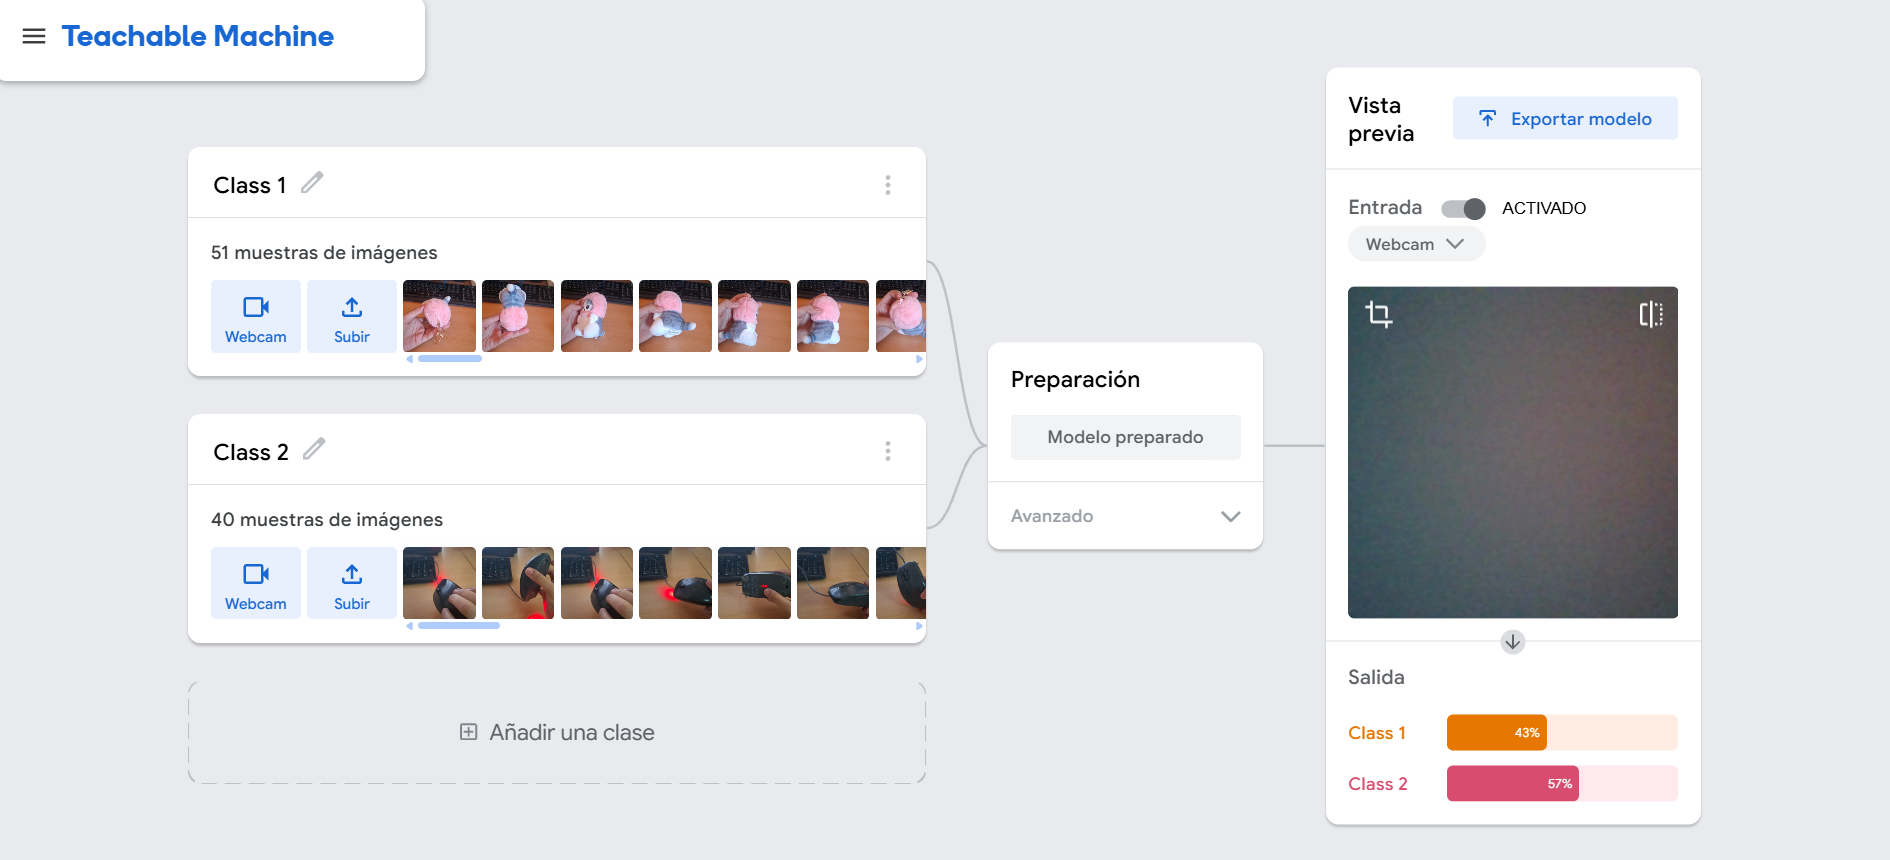

Luego he creado la estructura necesaria

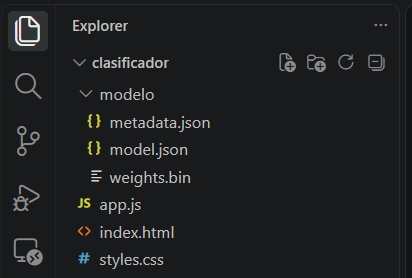

En app.js lo que hago es importar la librería de Teachable Machine (tmImage) y cargar los archivos .json del modelo desde la carpeta modelo.

En la carpeta modelo existe el modelo que hemos hecho y exportado en el Teachable Machine

Este es el body del codigo index.html

In [ ]:
<body>
  <div class="container">
    <header>
      <h1>Clasificador de Imágenes en Tiempo Real</h1>
      <p>Prueba el modelo entrenado con cámara o subiendo una imagen.</p>
    </header>

    <main class="main-content">
      <section class="card">
        <h2>Detección por Cámara</h2>
        <div class="controls">
          <button id="btn-start" class="btn btn-primary" onclick="init()">▶ Iniciar Cámara</button>
          <button id="btn-stop" class="btn btn-danger" onclick="stopWebcam()" disabled>⏹ Parar Cámara</button>
        </div>
        <div id="webcam-container" class="media-box"></div>
      </section>

      <section class="card">
        <h2>Clasificar Imagen Local</h2>
        <div class="controls">
          <input type="file" id="image-upload" accept="image/*" onchange="handleImageUpload(event)">
        </div>
        <div id="uploaded-image-container" class="media-box">
          <img id="uploaded-image" src="" alt="Imagen a clasificar" style="display:none;">
        </div>
      </section>

      <section class="card">
        <h2>Ajustes y Coincidencias</h2>

        <div class="threshold-setting">
          <label for="threshold">Valor mínimo de coincidencia (Umbral): <span id="threshold-val">60</span>%</label>
          <input type="range" id="threshold" min="0" max="100" value="60" oninput="updateThreshold(this.value)">
        </div>

        <div id="custom-message" class="alert-box">
          Estado: Esperando inicio de detección...
        </div>

        <h3>Predicciones Actuales</h3>
        <div id="label-container" class="labels-list"></div>
      </section>

      <section class="card full-width">
        <h2>Histórico de Coincidencias</h2>
        <ul id="history-list" class="history-log"></ul>
      </section>
    </main>
  </div>

  <script src="app.js"></script>
</body>

Este es el codigo js

In [ ]:
const URL_MODEL = "./modelo/";

let model, webcam, labelContainer, maxPredictions;
let isWebcamActive = false;
let minThreshold = 0.60;
let lastLoggedClass = "";

async function loadModel() {
  const modelURL = URL_MODEL + "model.json";
  const metadataURL = URL_MODEL + "metadata.json";
  model = await tmImage.load(modelURL, metadataURL);
  maxPredictions = model.getTotalClasses();

  labelContainer = document.getElementById("label-container");
  labelContainer.innerHTML = "";
  for (let i = 0; i < maxPredictions; i++) {
    labelContainer.appendChild(document.createElement("div"));
  }
}

async function init() {
  if (!model) await loadModel();

  const flip = true;
  webcam = new tmImage.Webcam(250, 250, flip);
  await webcam.setup();
  await webcam.play();
  isWebcamActive = true;

  document.getElementById("webcam-container").innerHTML = "";
  document.getElementById("webcam-container").appendChild(webcam.canvas);

  document.getElementById("btn-start").disabled = true;
  document.getElementById("btn-stop").disabled = false;

  window.requestAnimationFrame(loop);
}

async function loop() {
  if (isWebcamActive) {
    webcam.update();
    await predict(webcam.canvas);
    window.requestAnimationFrame(loop);
  }
}

function stopWebcam() {
  isWebcamActive = false;
  if (webcam) {
    webcam.stop();
  }
  document.getElementById("btn-start").disabled = false;
  document.getElementById("btn-stop").disabled = true;
  document.getElementById("custom-message").innerText = "Cámara detenida.";
}

async function predict(imageElement) {
  const prediction = await model.predict(imageElement);
  let highestPrediction = { className: "", probability: 0 };

  for (let i = 0; i < maxPredictions; i++) {
    const prob = prediction[i].probability;
    const classTitle = prediction[i].className;

    labelContainer.childNodes[i].innerHTML =
      `<strong>${classTitle}:</strong> ${(prob * 100).toFixed(1)}%`;

    if (prob > highestPrediction.probability) {
      highestPrediction = { className: classTitle, probability: prob };
    }
  }

  const messageBox = document.getElementById("custom-message");
  if (highestPrediction.probability >= minThreshold) {
    messageBox.className = "alert-box";
    messageBox.innerHTML = `Detección superó el umbral: <strong>${highestPrediction.className}</strong> (${(highestPrediction.probability * 100).toFixed(1)}%)`;

    if (lastLoggedClass !== highestPrediction.className) {
      addHistoryLog(highestPrediction.className, highestPrediction.probability);
      lastLoggedClass = highestPrediction.className;
    }
  } else {
    messageBox.className = "alert-box";
    messageBox.innerHTML = `Ninguna categoría supera el umbral mínimo de (${(minThreshold * 100).toFixed(0)}%).`;
  }
}

function updateThreshold(val) {
  minThreshold = val / 100;
  document.getElementById("threshold-val").innerText = val;
}

// Histórico
function addHistoryLog(className, probability) {
  const historyList = document.getElementById("history-list");
  const entry = document.createElement("li");
  const time = new Date().toLocaleTimeString();
  entry.innerText = `[${time}] Se detectó "${className}" con ${(probability * 100).toFixed(1)}% de precisión.`;
  historyList.prepend(entry);
}

async function handleImageUpload(event) {
  if (!model) await loadModel();

  const file = event.target.files[0];
  if (!file) return;

  const imgElement = document.getElementById("uploaded-image");
  imgElement.src = URL.createObjectURL(file);
  imgElement.style.display = "block";

  imgElement.onload = async function() {
    if (isWebcamActive) stopWebcam();
    await predict(imgElement);
  };
}

loadModel();

El archivo JavaScript se encarga de conectar la interfaz de la web con el modelo de inteligencia artificial




**Algunas explicaciones importantes :**

1- URL_MODEL: Guarda la ruta relativa donde están los archivos del modelo guardados en el proyecto.

2- model, webcam, labelContainer, maxPredictions: Se declaran arriba para que cualquier función del código pueda usarlas.

3- isWebcamActive: Un booleano que me sirve de interruptor para saber si la cámara está encendida o no.

4- minThreshold: El umbral o porcentaje mínimo de confianza para dar por buena una detección.

5-lastLoggedClass: Guarda la última categoría detectada para no saturar el historial repitiendo la misma palabra una y otra vez mientras sostienes el mismo objeto.

**---Con el modelo LoadModel---**

1- Junta la ruta con los archivos model.json y metadata.json y usa tmImage.load() para cargar la red neuronal. Lleva await porque la carga no es instantanea.

2- Con getTotalClasses() descubre cuántas etiquetas existen

3- Luego limpia el contenedor de etiquetas en la pantalla y crea mediante un bucle for un div nuevo para cada clase, dejándolo listo para ir escribiendo ahí los porcentajes

**---Con init---**

1- Comprueba si el modelo ya está cargado, si no, lo carga antes de nada

2- Crea el objeto de la cámara con tamaño $250 \times 250$ píxeles y con flip = true para que funcione en modo espejo.

3- Solicita permisos al navegador, arranca la imagen y marca isWebcamActive = true

4-Arranca la animación continua llamando a requestAnimationFrame

**---Con predict---**

1- Pasa el elemento de imagen al modelo con model.predict().

2- Recorre todas las predicciones para formatear la probabilidad en porcentaje con un solo decimal (.toFixed(1)) y actualiza las barras de pantalla.

3- Va buscando la predicción más alta guardándola en highestPrediction.

4- Compara el porcentaje más alto con minThreshold:

Si lo supera: muestra un mensaje  éxito y si la clase ha cambiado respecto a la anterior (lastLoggedClass), llama a addHistoryLog().

Si no lo supera muestra un aviso advirtiendo de que no hay suficiente precisión

**---Con handleImageUpload---**

1- Detecta la selección de un archivo local.

2- Genera una URL temporal con URL.createObjectURL para mostrar la imagen en un elemento img.

3- Cuando la imagen termina de cargarse en pantalla , si la cámara en vivo estaba encendida la apaga y le pasa directamente el elemento de la imagen a predict() para clasificar la foto estática-

**---Con updateThreshold y addHistoryLog---**

1- updateThreshold: Convierte el valor del slider a decimal para actualizar minThreshold al vuelo y refresca el número que ve el usuario.

2- addHistoryLog: Obtiene la hora actual del sistema, crea un elemento de lista li formateado y lo coloca arriba del todo en la lista de historial del HTML.

**---Con stopWebcam---**

1- Cambia el estado a false para romper el bucle de refresco.

2- Apaga el hardware de la cámara con webcam.stop() para liberar memoria y apagar el LED del ordenador.

3- Restablece los botones y actualiza el cuadro de texto notificando que la cámara se ha parado.

En resumen simple :  El código JavaScript carga de forma asíncrona el modelo (model.json y metadata.json) y prepara la interfaz web para mostrar los resultados. Al pulsar en iniciar, activa la webcam a $250 \times 250$ pixeles en modo espejo y pone en marcha un bucle que analiza cada fotograma en tiempo real con predict(), calculando los porcentajes de acierto de cada clase. Si la categoría con mayor puntuación supera el umbral configurado (minThreshold), la web muestra una alerta de exito y guarda la deteccion con la hora exacta en el historial sin repetir la misma clase seguidamente. Por ultimo incluye funciones para detener la cámara y liberar recursos, ajustar la sensibilidad del slider sobre la marcha y subir fotos locales para clasificarlas sin necesidad de usar la webcam.

Luego con un index.html y css , tengo esta página como resultado.

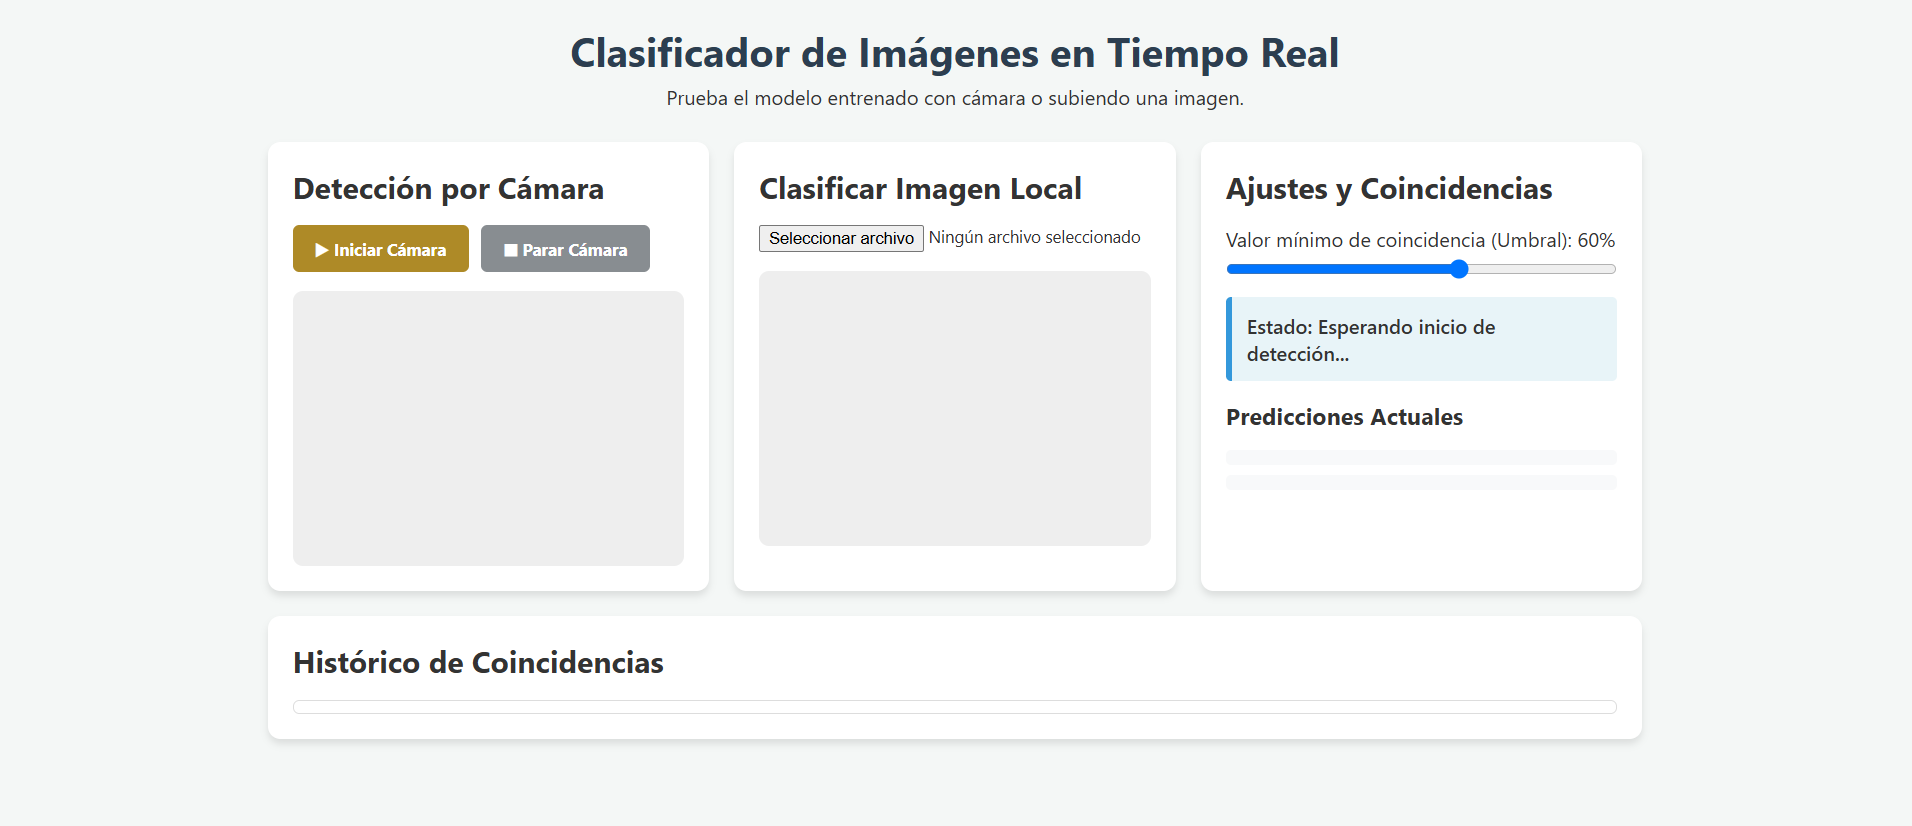

Lo he propado con el mando , y lo está pillando como elemnto clase 2 , que era un ratón

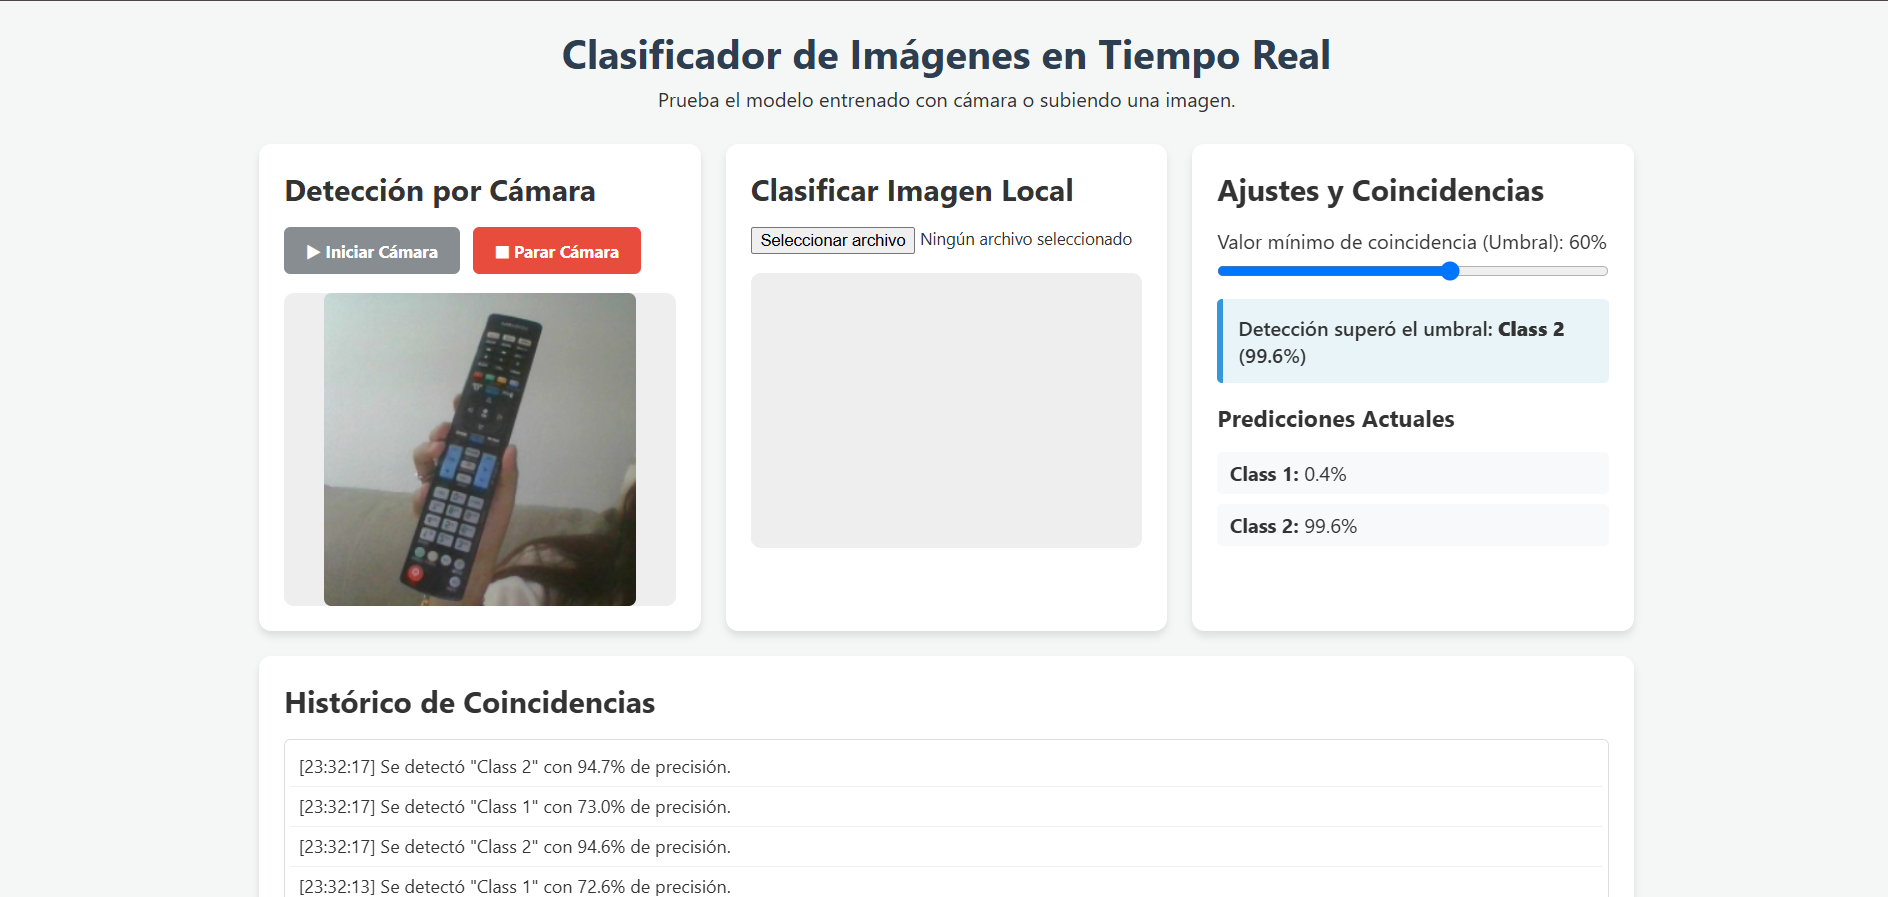

Ahora vamos a intentar subir un archivo, y el resultado sería :

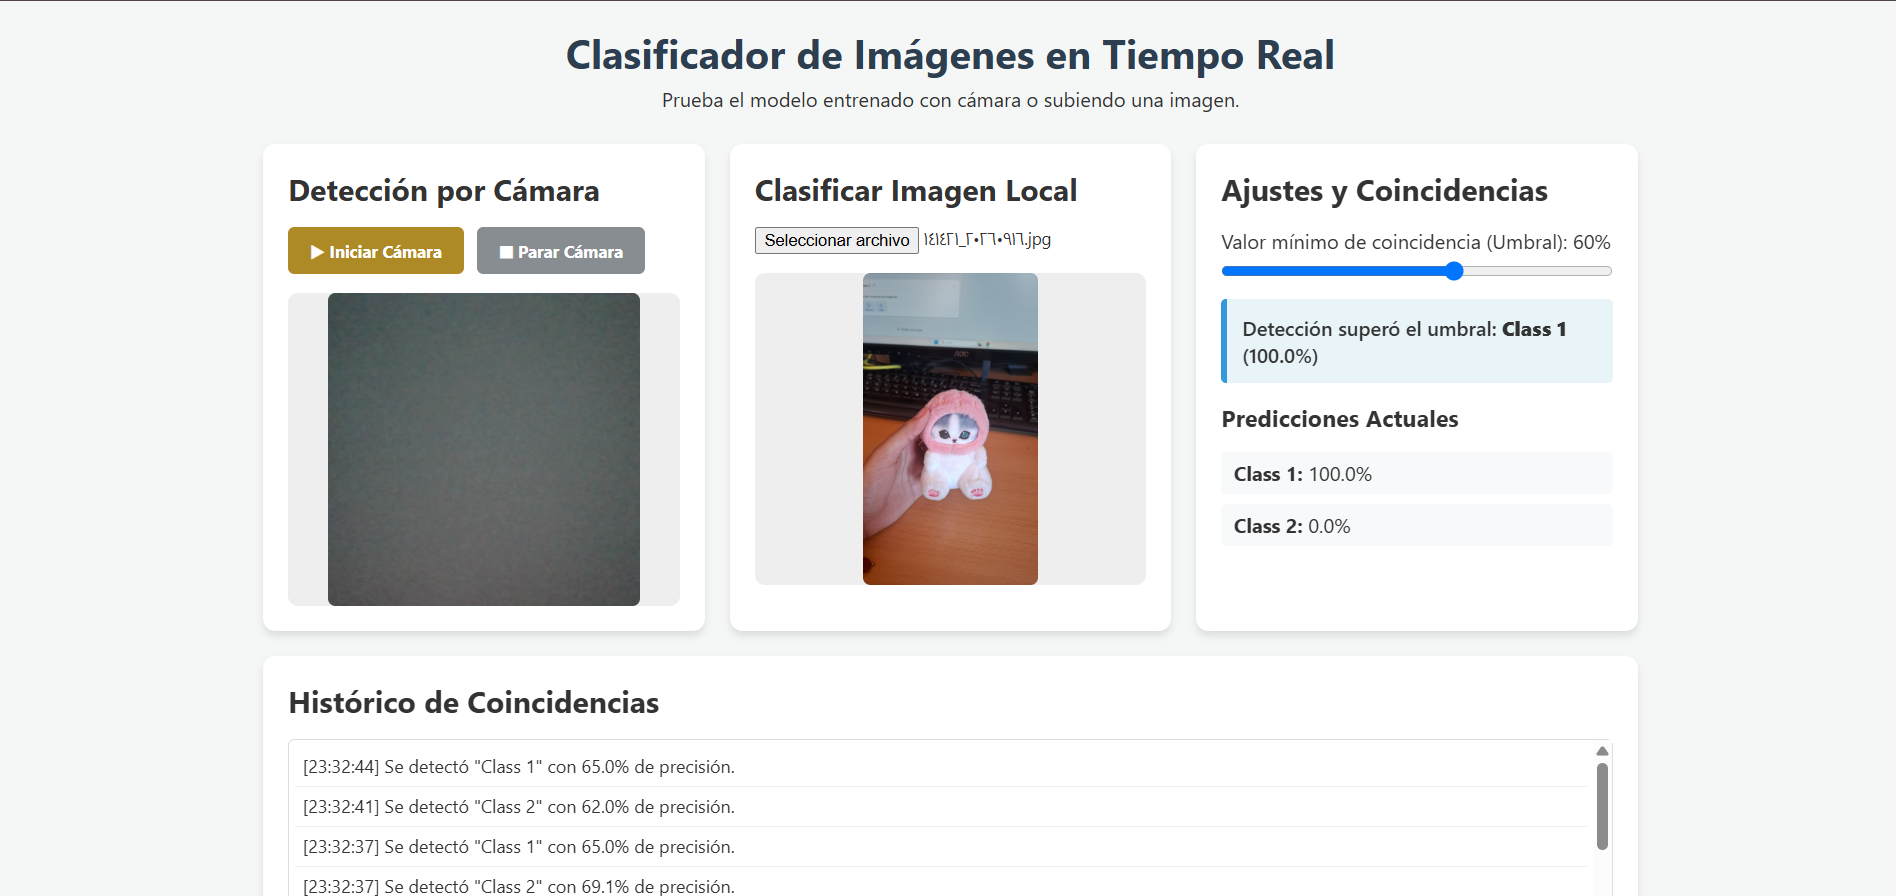

Pues exactamente, ya lo pillo el 100% porque esto era el elemento de la clase 1